<a href="https://colab.research.google.com/github/o0meerkat0o/butterfly_classifier/blob/main/monarch_life_stage_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monarch Life Stage Classifier

Classifies iNaturalist monarch photos into `adult / egg / larva / pupa` with two EfficientNet setups (B0 baseline, B1 fine-tuned).

Pipeline: auto-crop the subject with Grounding DINO, load + split the data, train, then look at the confusion matrix.

**Run the cells top to bottom.** Set your data path in the Config cell.

## Step 0. Runtime

The crop step uses a GPU. Set one before running: **Runtime > Change runtime type > T4 GPU** (free).

Everything works on CPU, but detection loop is slower.

In [ ]:
# check for a GPU and install the two libs Colab doesn't ship by default
!nvidia-smi -L || echo "No GPU found. Detection will run on CPU (slower)."
!pip install -q -U transformers timm

GPU 0: Tesla T4 (UUID: GPU-c86554c8-2d85-88e6-4b31-c477919468b5)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 105.4 MB/s eta 0:00:00


## Step 1. Get the data into Colab

Mounted Drive folder holding the class subfolders (`adult/`, `egg/`, `larva/`, `pupa/`).

In [ ]:
# mount Drive if that's where your images live
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2. Config

One place for the knobs. Point `DATA_DIR` at the folder that contains the four class subfolders.

In [ ]:
from pathlib import Path

# folder containing adult/ egg/ larva/ pupa/
# original local path was: /home/mc3227/inat_leps_urban_study/data/training_data/combined
DATA_DIR    = '/content/drive/MyDrive/ento lab/training_data'

OUTPUT_DIR  = "/content/drive/MyDrive/ento lab/output"            # trained models + logs land here
CROPPED_DIR = "/content/drive/MyDrive/ento lab/combined_cropped"  # cropped copies land here

IMG_SIZE   = (240, 240)   # EfficientNetB1's native res. B0 (native 224) runs fine here too, one dataset feeds both
BATCH_SIZE = 32
VAL_SPLIT  = 0.2
SEED       = 42
EPOCHS     = 30
USE_CROPPED = True        # False = train on the raw uncropped images

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

## Step 3. Auto bounding boxes with Grounding DINO

Field photos have the subject buried in leaves and sky. Detecting it and cropping in gives the classifier a cleaner input. Grounding DINO is an open-vocabulary detector: hand it a text prompt like `"a butterfly."` and it returns boxes, no training required.

### Automating the boxes for free

Options (all free):

- **Grounding DINO** (used below). Zero-shot from a text prompt. Runs on Colab's free T4.
- **Autodistill** (`autodistill-grounding-dino` / `autodistill-grounded-sam`). Wraps the same models but auto-labels a whole folder from an ontology dict and exports YOLO / COCO / VOC files. Use this if you want saved annotation files, not just crops.
- **Grounded SAM / SAM 2**. Same idea, but returns pixel masks on top of the boxes. Overkill if boxes are all you need.
- **Roboflow Annotate**. Free tier, browser-based. Its Auto Label / Label Assist run Grounding DINO + SAM server-side so you review instead of draw.
- **CVAT, Make Sense, Label Studio**. Free and open-source. Manual, but with ML-assisted suggestions.

Caveat: foundation models nail common objects (butterfly, caterpillar) but get shaky on tiny or fine-grained ones. Eggs especially. That's why the crop step below falls back to the full image whenever nothing is found, so no sample gets lost.

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

device = "cuda" if torch.cuda.is_available() else "cpu"

# tiny is fast and fine for one clear subject per photo. swap to -base for a little more accuracy
GD_MODEL_ID = "IDEA-Research/grounding-dino-tiny"
processor = AutoProcessor.from_pretrained(GD_MODEL_ID)
gd_model  = AutoModelForZeroShotObjectDetection.from_pretrained(GD_MODEL_ID).to(device).eval()

# class-specific prompts: DINO detects better from one targeted noun than a long OR-list.
# prompts must be lowercase and end with a period
PROMPTS = {
    "adult": "a butterfly.",
    "larva": "a caterpillar.",
    "pupa":  "a chrysalis.",
    "egg":   "an insect egg on a leaf.",
}
DEFAULT_PROMPT = "an insect."

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from PIL import Image

def detect_boxes(pil_img, prompt, box_thr=0.30, text_thr=0.25):
    """Return (boxes [x0,y0,x1,y1], scores). Empty arrays when nothing is found."""
    inputs = processor(images=pil_img, text=prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = gd_model(**inputs)
    # transformers renamed box_threshold -> threshold around v4.51, so try new signature then old
    common = dict(target_sizes=[pil_img.size[::-1]], text_threshold=text_thr)
    try:
        res = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, threshold=box_thr, **common)[0]
    except TypeError:
        res = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, box_threshold=box_thr, **common)[0]
    return res["boxes"].cpu().numpy(), res["scores"].cpu().numpy()


def crop_to_subject(pil_img, boxes, scores, pad=0.08, min_score=0.30):
    """Crop to the union of confident boxes, padded. Returns the full image if nothing qualifies."""
    if len(boxes) == 0:
        return pil_img
    keep = scores >= min_score
    boxes = boxes[keep] if keep.any() else boxes
    x0, y0 = boxes[:, 0].min(), boxes[:, 1].min()
    x1, y1 = boxes[:, 2].max(), boxes[:, 3].max()   # union box covers every detection
    w, h = pil_img.size
    px, py = (x1 - x0) * pad, (y1 - y0) * pad        # pad so wings/antennae don't get clipped
    return pil_img.crop((max(0, x0 - px), max(0, y0 - py),
                         min(w, x1 + px), min(h, y1 + py)))

Sanity-check the prompts on a random sample from each class before cropping

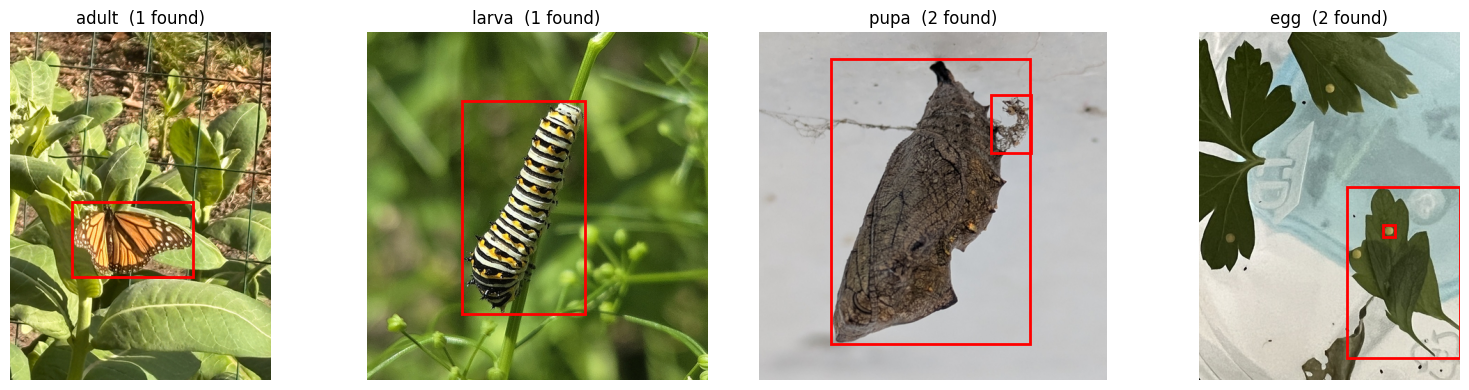

In [ ]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_classes = [c for c in PROMPTS if os.path.isdir(os.path.join(DATA_DIR, c))]
fig, axes = plt.subplots(1, len(sample_classes), figsize=(4 * len(sample_classes), 4))
axes = np.atleast_1d(axes)

for ax, cls in zip(axes, sample_classes):
    f = random.choice(os.listdir(os.path.join(DATA_DIR, cls)))
    img = Image.open(os.path.join(DATA_DIR, cls, f)).convert("RGB")
    boxes, scores = detect_boxes(img, PROMPTS[cls])
    ax.imshow(img); ax.axis("off"); ax.set_title(f"{cls}  ({len(boxes)} found)")
    for (bx0, by0, bx1, by1) in boxes:
        ax.add_patch(patches.Rectangle((bx0, by0), bx1 - bx0, by1 - by0,
                                       fill=False, edgecolor="red", linewidth=2))
plt.tight_layout(); plt.show()

Now crop the whole dataset into `CROPPED_DIR`, keeping the class subfolders. Non-destructive (originals stay put)

In [ ]:
import shutil
from tqdm.auto import tqdm

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def build_cropped_dataset(src_dir, dst_dir):
    if os.path.exists(dst_dir):
        shutil.rmtree(dst_dir)   # start clean so reruns don't stack up
    for cls in sorted(os.listdir(src_dir)):
        src_cls = os.path.join(src_dir, cls)
        if not os.path.isdir(src_cls):
            continue
        dst_cls = os.path.join(dst_dir, cls)
        os.makedirs(dst_cls, exist_ok=True)
        prompt = PROMPTS.get(cls, DEFAULT_PROMPT)
        files = [f for f in os.listdir(src_cls)
                 if os.path.splitext(f)[1].lower() in VALID_EXT]
        for f in tqdm(files, desc=cls):
            try:
                img = Image.open(os.path.join(src_cls, f)).convert("RGB")
            except Exception:
                continue         # skip unreadable/corrupt files
            boxes, scores = detect_boxes(img, prompt)
            crop_to_subject(img, boxes, scores).save(os.path.join(dst_cls, f))

if USE_CROPPED:
    build_cropped_dataset(DATA_DIR, CROPPED_DIR)
    DATA_DIR = CROPPED_DIR       # everything below now reads the cropped copies
    print("Using cropped images at", DATA_DIR)
else:
    print("Skipping crop, using raw images at", DATA_DIR)

adult:   0%|          | 0/1000 [00:00<?, ?it/s]

egg:   0%|          | 0/810 [00:00<?, ?it/s]

larva:   0%|          | 0/907 [00:00<?, ?it/s]

pupa:   0%|          | 0/900 [00:00<?, ?it/s]

Using cropped images at /content/drive/MyDrive/ento lab/combined_cropped


## Step 4. Load and split

Uses `validation_split` + `subset` for the train/val split. Same `seed` on both calls keeps them complementary.

In [ ]:
import tensorflow as tf

common = dict(image_size=IMG_SIZE, batch_size=BATCH_SIZE,
              label_mode="categorical", seed=SEED)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="training", **common)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="validation", **common)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

Found 3617 files belonging to 4 classes.
Using 2894 files for training.
Found 3617 files belonging to 4 classes.
Using 723 files for validation.
Classes: ['adult', 'egg', 'larva', 'pupa']


iNaturalist skews heavily toward adults, so weight the loss by inverse class frequency.

In [ ]:
import numpy as np
import os, random
# inverse-frequency weights: rarer stages (eggs, pupae) count for more
counts = np.array([len(os.listdir(os.path.join(DATA_DIR, c))) for c in CLASS_NAMES], dtype=float)
class_weights = {i: counts.sum() / (len(counts) * n) for i, n in enumerate(counts)}

print("counts :", dict(zip(CLASS_NAMES, counts.astype(int))))
print("weights:", {CLASS_NAMES[i]: round(w, 2) for i, w in class_weights.items()})

counts : {'adult': np.int64(1000), 'egg': np.int64(810), 'larva': np.int64(907), 'pupa': np.int64(900)}
weights: {'adult': np.float64(0.9), 'egg': np.float64(1.12), 'larva': np.float64(1.0), 'pupa': np.float64(1.0)}


## Step 5. Model 1, B0 baseline

Frozen EfficientNetB0 backbone, single dense head. Fast to train, sets a floor to beat.

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetB0

# keras.applications EfficientNet normalizes internally and expects raw 0-255 pixels,
# which is exactly what image_dataset_from_directory returns, so NO Rescaling layer here
backbone_b0 = EfficientNetB0(include_top=False, weights="imagenet",
                             input_shape=(*IMG_SIZE, 3), pooling="avg")
backbone_b0.trainable = False   # baseline trains the head only

model_01 = Sequential([
    layers.Input((*IMG_SIZE, 3)),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    backbone_b0,
    layers.Dropout(0.3),
    layers.Dense(len(CLASS_NAMES), activation="softmax"),
], name="butterfly_efficientnetb0_baseline")

model_01.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)
model_01.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "butterfly_efficientnetb0_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 240, 240, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Step 6. Model 2, B1 fine-tuned

Bigger backbone with the top 20 layers unfrozen, a richer augmentation stack tuned for field photos, a small bottleneck head, and label smoothing. This is the one meant to actually perform.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers.schedules import CosineDecay

backbone_b1 = EfficientNetB1(include_top=False, weights="imagenet",
                             input_shape=(*IMG_SIZE, 3), pooling="avg")

# fine-tune only the top of the backbone, earlier layers keep their generic imagenet features
backbone_b1.trainable = True
for layer in backbone_b1.layers[:-20]:
    layer.trainable = False

inputs = layers.Input((*IMG_SIZE, 3))
x = layers.RandomFlip("horizontal")(inputs)   # horizontal only, butterflies are L-R symmetric
x = layers.RandomRotation(0.15)(x)
x = layers.RandomZoom(0.15)(x)
x = layers.RandomTranslation(0.1, 0.1)(x)      # subject isn't always centered in field photos
x = layers.RandomContrast(0.2)(x)              # varied outdoor lighting
x = layers.RandomBrightness(0.2)(x)

x = backbone_b1(x, training=False)             # training=False keeps BatchNorm stats frozen

x = layers.Dense(128, use_bias=False)(x)       # small bottleneck head, bias is redundant before BN
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model_02 = Model(inputs, outputs, name="butterfly_efficientnetb1")

# decay the LR over the actual run length instead of a hardcoded step count
steps_per_epoch = int(train_ds.cardinality().numpy())
lr_schedule = CosineDecay(initial_learning_rate=1e-4,
                          decay_steps=steps_per_epoch * EPOCHS,
                          alpha=1e-6)           # floor the LR at ~1e-6 rather than 0

model_02.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # softens overconfident labels
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")],   # more informative than accuracy under imbalance
)
model_02.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "butterfly_efficientnetb1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 240, 240, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 240, 240, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 240, 240, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 240, 240, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 1280)           │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,740,107 (25.71 MB)

 Trainable params: 2,141,012 (8.17 MB)

 Non-trainable params: 4,599,095 (17.54 MB)

## Step 7. Train

`ModelCheckpoint` saves the best val-loss weights, `EarlyStopping` bails once val loss plateaus. Best model is written to `OUTPUT_DIR/model_02.keras`.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint

callbacks_02 = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ModelCheckpoint(os.path.join(OUTPUT_DIR, "model_02.keras"),
                    monitor="val_loss", save_best_only=True),
    CSVLogger(os.path.join(OUTPUT_DIR, "model_02_log.csv")),
]

history_02 = model_02.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,     # counter the adult-heavy imbalance
    callbacks=callbacks_02,
)
model_02.save(os.path.join(OUTPUT_DIR, "model_02.keras"))

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 733s 8s/step - accuracy: 0.6296 - auc: 0.8520 - loss: 1.1004 - precision: 0.7149 - recall: 0.5415 - val_accuracy: 0.9018 - val_auc: 0.9759 - val_loss: 0.6513 - val_precision: 0.9537 - val_recall: 0.7690
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - accuracy: 0.7947 - auc: 0.9436 - loss: 0.8057 - precision: 0.8533 - recall: 0.7256 - val_accuracy: 0.9184 - val_auc: 0.9840 - val_loss: 0.5676 - val_precision: 0.9505 - val_recall: 0.8769
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.8366 - auc: 0.9619 - loss: 0.7232 - precision: 0.8863 - recall: 0.7809 - val_accuracy: 0.9336 - val_auc: 0.9851 - val_loss: 0.5544 - val_precision: 0.9475 - val_recall: 0.8990
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.8635 - auc: 0.9738 - loss: 0.6621 - precision: 0.9007 - recall: 0.8151 - val_accuracy: 0.9364 - val_auc: 0.9863 - val_loss: 0.5411 - val_precision: 0.9479 - val_recall: 0.9059
Epoch 5/30
91/91 ━━━━━━━━━━━━━

Optional: quick baseline run for model_01 so you have something to compare against. Frozen backbone trains fast, so a few epochs is plenty.

In [ ]:
history_01 = model_01.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
)
model_01.save(os.path.join(OUTPUT_DIR, "model_01.keras"))

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 193ms/step - accuracy: 0.7429 - loss: 0.7134 - precision: 0.8647 - recall: 0.6071 - val_accuracy: 0.8866 - val_loss: 0.3751 - val_precision: 0.9234 - val_recall: 0.8506
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 161ms/step - accuracy: 0.8518 - loss: 0.4462 - precision: 0.8919 - recall: 0.8072 - val_accuracy: 0.9046 - val_loss: 0.3245 - val_precision: 0.9260 - val_recall: 0.8824
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 160ms/step - accuracy: 0.8756 - loss: 0.3834 - precision: 0.9072 - recall: 0.8411 - val_accuracy: 0.9184 - val_loss: 0.2871 - val_precision: 0.9355 - val_recall: 0.9032
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.8922 - loss: 0.3402 - precision: 0.9194 - recall: 0.8597 - val_accuracy: 0.9170 - val_loss: 0.2753 - val_precision: 0.9355 - val_recall: 0.9032
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.8891 - loss: 0.3267 - precision: 0.9208 - recall: 0.8594 - val_accuracy: 0.9212 - val_los

Training curves for model_02.

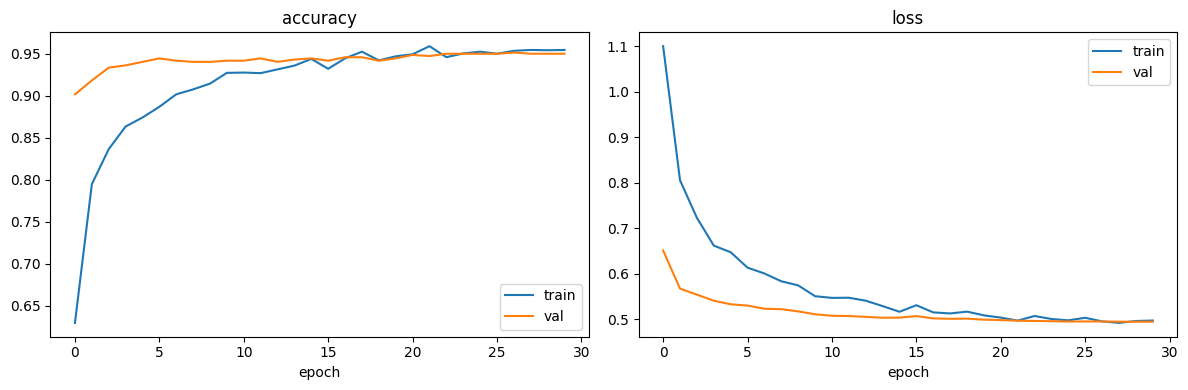

In [ ]:
import matplotlib.pyplot as plt
h = history_02.history
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(h["accuracy"], label="train"); a1.plot(h["val_accuracy"], label="val")
a1.set_title("accuracy"); a1.set_xlabel("epoch"); a1.legend()
a2.plot(h["loss"], label="train"); a2.plot(h["val_loss"], label="val")
a2.set_title("loss"); a2.set_xlabel("epoch"); a2.legend()
plt.tight_layout(); plt.show()

## Step 8. Confusion matrix

Collects predictions and labels in a **single pass** over the val set, so they stay aligned even though the dataset reshuffles. Running `predict` and label-gathering as two separate loops (like the original snippet) would misalign them and produce a garbage matrix.

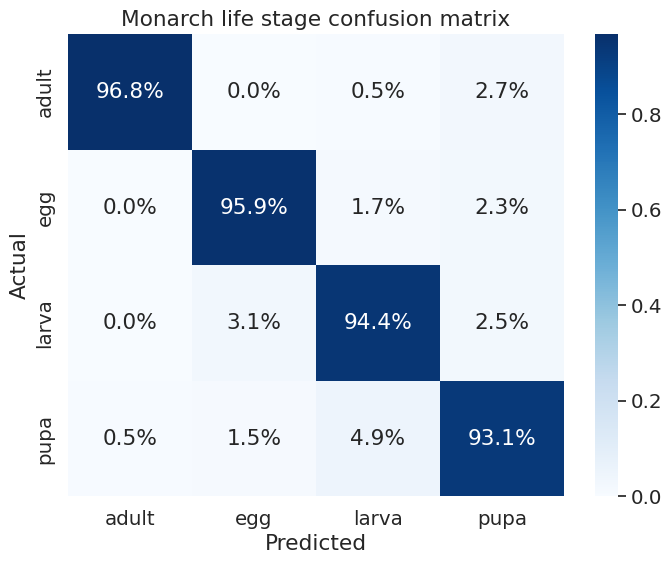

              precision    recall  f1-score   support

       adult       0.99      0.97      0.98       187
         egg       0.95      0.96      0.96       172
       larva       0.92      0.94      0.93       161
        pupa       0.94      0.93      0.93       203

    accuracy                           0.95       723
   macro avg       0.95      0.95      0.95       723
weighted avg       0.95      0.95      0.95       723



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

model = tf.keras.models.load_model(os.path.join(OUTPUT_DIR, "model_02.keras"))

y_true, y_pred = [], []
for x, y in val_ds:                       # one pass keeps preds and labels in lockstep
    p = model.predict(x, verbose=0)
    y_true.append(np.argmax(y, axis=1))
    y_pred.append(np.argmax(p, axis=1))
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

cm = pd.DataFrame(confusion_matrix(y_true, y_pred), index=CLASS_NAMES, columns=CLASS_NAMES)
cm_norm = cm.div(cm.sum(axis=1), axis=0)  # row-normalize, so the diagonal reads as per-class recall

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.3)
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("All butterfiles life stage confusion matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))